# EDA: что уже лежит в бакете

Первый прогон связки **бакет → манифесты → ClearML**. Тяжёлые данные не трогаются:
вся аналитика идёт по манифестам, это сотни килобайт на десять тысяч кадров.

## Как запустить

Из VS Code через удалённое ядро DataSphere: в интерфейсе проекта включить
«Режим работы проектов → Подключение внешних IDE» (терраформом не
настраивается — поля нет ни в провайдере, ни в `yc`), затем расширение
Yandex Cloud DataSphere, подключение к проекту, выбор ядра.

**Главная ловушка этого режима: код выполняется на удалённой машине.**
Локальный `.env` на неё не попадает, и переменные окружения надо заводить
секретами проекта. Ячейки 1 и 2 показывают, где ядро на самом деле, и что
именно делать в каждом случае.

Секретов в этом файле нет и быть не должно.


## 1. Где выполняется ядро

Первым делом — понять, где именно исполняется код. При работе из VS Code через
удалённое ядро DataSphere локальные файлы, включая `.env`, на исполнение никак
не влияют: они лежат на вашей машине, а код работает на чужой.

In [37]:
import os, platform, socket, sys

# DATASPHERE_PROJECT_ID и JUPYTER_IMAGE в ядре не выставлены — определяем по
# фактическим приметам: рабочий каталог /home/jupyter и служебное имя хоста.
remote = (os.getcwd().startswith("/home/jupyter")
          or socket.gethostname().startswith("s-")
          or os.path.isdir("/kernel"))

print("хост      :", socket.gethostname())
print("система   :", platform.platform())
print("python    :", sys.executable)
print("каталог   :", os.getcwd())
print("похоже на :", "удалённое ядро DataSphere" if remote else "локальное ядро")

хост      : s-8b766727-ab9a-331e-bb95-69b682d444d5
система   : Linux-5.4.0-216-generic-x86_64-with-glibc2.35
python    : /usr/local/bin/python3
каталог   : /home/jupyter
похоже на : удалённое ядро DataSphere


## 2. Конфигурация и секреты

Секреты берутся только из переменных окружения. Откуда они там появляются —
зависит от того, что показала предыдущая ячейка.

**Удалённое ядро DataSphere.** Проект → Настройки → Секреты, завести
`S3_KEY`, `S3_SECRET`, `CLEARML_API_ACCESS_KEY`, `CLEARML_API_SECRET_KEY`.
После добавления **перезапустить ядро** — секреты подставляются при его
старте, на живое ядро не приезжают. Локальный `.env` тут бесполезен.

**Локальное ядро.** Подхватится `.env` из корня репозитория, если установлен
`python-dotenv`.

Значения: ключи S3 — `tofu output -raw datasphere_s3_access_key` и
`-raw datasphere_s3_secret_key`; ключи ClearML — в веб-интерфейсе,
Settings → Workspace → Create new credentials.

Разовый обход для проверки, без сохранения в файл: выполнить в отдельной
ячейке `%env S3_KEY=...`. В сам блокнот секреты не вписывать.

In [38]:
BUCKET   = os.environ.get("DATASETS_BUCKET", "occlusionnet-clearml-b052c3-datasets")
ENDPOINT = "https://storage.yandexcloud.net"
REGION   = "ru-central1"

CLEARML_PROJECT = "OcclusionNet"
CLEARML_TASK    = "eda-manifests"

if not remote:                       # для локального ядра .env имеет смысл
    try:
        from dotenv import load_dotenv, find_dotenv
        if path := find_dotenv(usecwd=True):
            load_dotenv(path)
            print("подхвачен", path)
    except ImportError:
        print("python-dotenv не установлен — переменные только из окружения")

missing = [k for k in ("S3_KEY", "S3_SECRET") if not os.environ.get(k)]
print("бакет         :", BUCKET)
print("секреты S3    :", "на месте" if not missing else f"НЕ ЗАДАНЫ: {missing}")
print("секреты ClearML:", "на месте" if os.environ.get("CLEARML_API_ACCESS_KEY")
      else "нет — логирование пропустим")

if missing:
    raise RuntimeError(
        "Без ключей S3 дальше нельзя.\n"
        + ("Ядро удалённое: заведите секреты в проекте DataSphere "
           "(Настройки -> Секреты) и ПЕРЕЗАПУСТИТЕ ядро — на живое они не приезжают."
           if remote else
           "Ядро локальное: положите .env в корень репозитория или экспортируйте "
           "переменные в оболочке перед запуском VS Code."))

бакет         : occlusionnet-clearml-b052c3-datasets
секреты S3    : на месте
секреты ClearML: на месте


## 3. Бакет

Подключаемся через boto3: он одинаково работает и в DataSphere, и локально.
S3-коннектор DataSphere монтирует бакет в файловую систему, но тогда блокнот
перестаёт запускаться где-либо ещё.

In [39]:
%pip install -q boto3 pyarrow pandas matplotlib

import boto3, pandas as pd  # os импортирован выше

s3 = boto3.client(
    "s3", endpoint_url=ENDPOINT, region_name=REGION,
    aws_access_key_id=os.environ["S3_KEY"],
    aws_secret_access_key=os.environ["S3_SECRET"],
)

objs = []
paginator = s3.get_paginator("list_objects_v2")
for page in paginator.paginate(Bucket=BUCKET):
    objs.extend(page.get("Contents", []))

inv = pd.DataFrame([{"ключ": o["Key"],
                     "ГБ": round(o["Size"] / 1024**3, 3),
                     "изменён": o["LastModified"].strftime("%Y-%m-%d %H:%M")}
                    for o in objs]).sort_values("ключ")
print(f"объектов: {len(inv)}   суммарно: {inv['ГБ'].sum():.2f} ГБ\n")
inv


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
объектов: 5   суммарно: 9.72 ГБ



,ключ,ГБ,изменён
0,manifest/cadc.parquet,0.000,2026-08-16 14:39
1,manifest/evocargo.parquet,0.000,2026-08-15 09:35
2,raw/cadc/clear_lens.tar,1.326,2026-08-16 14:39
3,raw/cadc/lens_snow.tar,1.501,2026-08-16 14:38
4,raw/evocargo_raindrops/RaindropsOnWindshield.zip,6.895,2026-08-15 09:35


## 4. Манифесты

По строке на кадр. Скачиваются целиком — они маленькие, гигабайты сырья остаются
в бакете нетронутыми.

In [40]:
import io, pyarrow.parquet as pq

keys = [o["Key"] for o in objs if o["Key"].startswith("manifest/") and o["Key"].endswith(".parquet")]
frames = []
for k in keys:
    body = s3.get_object(Bucket=BUCKET, Key=k)["Body"].read()
    frames.append(pq.read_table(io.BytesIO(body)).to_pandas())
    print(f"{k}: {len(frames[-1]):,} строк, {len(body)/1024:.0f} КБ")

df = pd.concat(frames, ignore_index=True)
ok = df[df.error.isna()].copy()
ok["lab"] = ok.labels.apply(lambda l: "+".join(sorted(l)) or "clean")
ok["res"] = ok.width.astype(str) + "x" + ok.height.astype(str)

print(f"\nвсего кадров: {len(df):,}   читаемых: {len(ok):,}   сырья: {df.bytes.sum()/1024**3:.2f} ГБ")
if (bad := df.error.notna().sum()):
    print(f"нечитаемых файлов: {bad}")
    display(df[df.error.notna()][["source", "raw_path", "error"]])

manifest/cadc.parquet: 1,825 строк, 65 КБ
manifest/evocargo.parquet: 8,190 строк, 270 КБ

всего кадров: 10,015   читаемых: 10,014   сырья: 10.20 ГБ
нечитаемых файлов: 1


,source,raw_path,error
6336,evocargo_raindrops,images/D3/D3_0/D3_0321.png,OSError: broken data stream when reading image...


## 5. Что у нас есть

In [41]:
import collections

by_source = ok.groupby("source").agg(
    кадров=("frame_uid", "size"),
    сиквенсов=("sequence_id", "nunique"),
    ГБ=("bytes", lambda s: round(s.sum() / 1024**3, 2)),
    медиана_резкости=("sharpness", lambda s: round(s.median(), 1)),
)
display(by_source)

counts = collections.Counter(l for ls in ok.labels for l in ls)
counts["clean"] = int((ok.labels.apply(len) == 0).sum())
labels = pd.DataFrame({"метка": list(counts), "кадров": list(counts.values())})
labels["доля, %"] = (100 * labels.кадров / len(ok)).round(1)
display(labels.sort_values("кадров", ascending=False).reset_index(drop=True))

print("сочетания меток:")
display(ok.lab.value_counts().rename_axis("сочетание").to_frame("кадров"))

,кадров,сиквенсов,ГБ,медиана_резкости
source,,,,
cadc,1825,20,2.83,224.500000
evocargo_raindrops,8189,8,7.38,417.600006


,метка,кадров,"доля, %"
0,clean,4801,47.9
1,raindrops,3388,33.8
2,snowfall,1825,18.2
3,soiling,950,9.5


сочетания меток:


,кадров
сочетание,
clean,4801
raindrops,3388
snowfall+soiling,950
snowfall,875


## 6. Проверка на утечку

Главный вопрос к собранному датасету: можно ли угадать метку, не глядя на саму
помеху. Если да, модель выучит именно это.

Смотрим два подозреваемых — источник и разрешение кадра.

In [42]:
print("метка x источник")
display(pd.crosstab(ok.lab, ok.source))

print("метка x разрешение")
ct = pd.crosstab(ok.lab, ok.res)
display(ct)

# насколько хорошо разрешение предсказывает метку внутри одного источника
for src in ok.source.unique():
    sub = ok[ok.source == src]
    if sub.res.nunique() < 2:
        continue
    top = pd.crosstab(sub.res, sub.lab)
    acc = top.max(axis=1).sum() / len(sub)
    print(f"\n{src}: зная только разрешение, метка угадывается в {100*acc:.0f}% случаев")
    display(top)

метка x источник


source,cadc,evocargo_raindrops
lab,,
clean,0,4801
raindrops,0,3388
snowfall,875,0
snowfall+soiling,950,0


метка x разрешение


res,1280x1024,1920x1080
lab,,
clean,4000,801
raindrops,300,3088
snowfall,875,0
snowfall+soiling,950,0



evocargo_raindrops: зная только разрешение, метка угадывается в 87% случаев


lab,clean,raindrops
res,,
1280x1024,4000,300
1920x1080,801,3088


## 7. Графики

Палитра и правила оформления — из общего гайда: тонкие штрихи, приглушённая сетка,
значения подписаны прямо на столбцах, цвет никогда не единственный носитель
смысла.

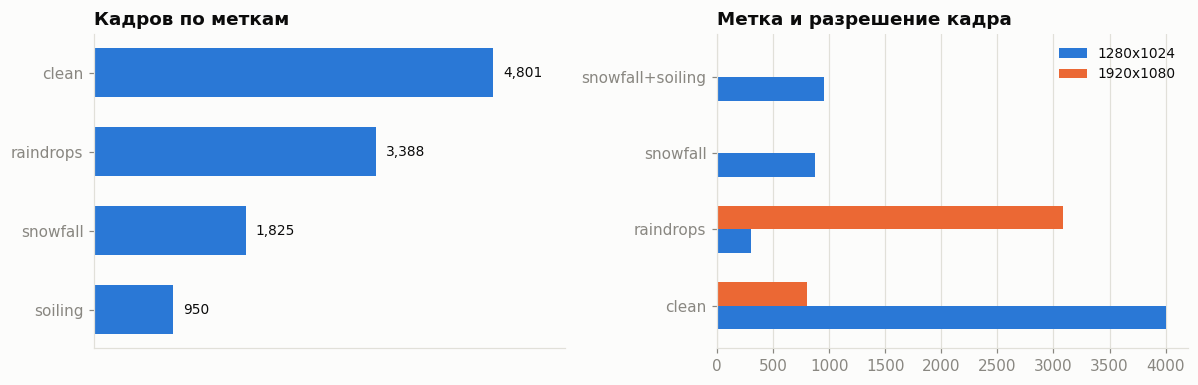

In [43]:
import matplotlib.pyplot as plt

INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
BLUE, ORANGE = "#2a78d6", "#eb6834"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.dpi": 110,
})

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))

d = labels.sort_values("кадров")
a1.barh(d.метка, d.кадров, color=BLUE, height=0.62)
for y, v in zip(d.метка, d.кадров):
    a1.text(v + len(ok) * 0.012, y, f"{v:,}", va="center", color=INK, fontsize=9)
a1.set_xlim(0, d.кадров.max() * 1.18)
a1.set_title("Кадров по меткам", loc="left", color=INK, fontweight="bold")
a1.xaxis.set_visible(False)
a1.grid(False)

# две серии — нужна легенда, цвет дублируется подписью
piv = pd.crosstab(ok.lab, ok.res)
piv.plot(kind="barh", ax=a2, color=[BLUE, ORANGE], width=0.62, legend=True)
a2.set_title("Метка и разрешение кадра", loc="left", color=INK, fontweight="bold")
a2.set_ylabel("")
a2.legend(title="", frameon=False, fontsize=9)
a2.xaxis.grid(True, color=GRID, linewidth=0.8)
a2.set_axisbelow(True)

fig.tight_layout()
plt.show()

## 8. Отправка в ClearML

Если сервер недоступен или ключи не заданы, ячейка не роняет блокнот — просто
сообщает и идёт дальше.

In [44]:
# Куда вообще ставятся пакеты. Здесь ломается чаще всего: %pip зовёт свой pip,
# а ядро может быть запущено другим интерпретатором, и установленное им не видно.
import site, subprocess, sys

print("интерпретатор ядра:", sys.executable)
print("pip этого ядра    :")
print(subprocess.run([sys.executable, "-m", "pip", "--version"],
                     capture_output=True, text=True).stdout.strip())
print("user site включён :", site.ENABLE_USER_SITE)
print("user site         :", site.getusersitepackages())
print("\nsys.path:")
for x in sys.path:
    print("  ", x or "(cwd)")

интерпретатор ядра: /usr/local/bin/python3
pip этого ядра    :
pip 26.1.1 from /kernel/lib/python3.10/site-packages/pip (python 3.10)
user site включён : True
user site         : /home/jupyter/.local/lib/python3.10/site-packages

sys.path:
   /home/jupyter
   /usr/lib/python310.zip
   /usr/lib/python3.10
   /usr/lib/python3.10/lib-dynload
   (cwd)
   /kernel/lib/python3.10/site-packages
   /usr/local/lib/python3.10/dist-packages
   /usr/lib/python3/dist-packages
   /kernel/fallback/lib/python3.10/site-packages
   /kernel/lib/python3.10/site-packages/ml_kernel/_vendor/IPython/extensions
   /kernel/lib/python3.10/site-packages/setuptools/_vendor
   /home/jupyter/.ipython
   /kernel/lib/python3.10/site-packages/ml_kernel/_vendor/IPython/extensions


In [ ]:
# Установка + конфиг хранилища для ClearML. Порядок важен: конфиг пишется ДО
# import clearml, потому что настройки читаются при первом обращении.
import os, subprocess, sys

LIBS = os.path.expanduser("~/dslibs")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "--target", LIBS, "clearml"])
if LIBS not in sys.path:
    sys.path.insert(0, LIBS)

# ClearML не видит наши S3_KEY и S3_SECRET: это имена для boto3 из ячейки 3.
# У него свой слой хранилища, и ключи он берёт из ~/clearml.conf. Переменные
# AWS_ACCESS_KEY_ID тоже не подошли бы — для не-амазоновского эндпоинта нужна
# запись с полем host, иначе он пойдёт в настоящий AWS.
#
# Секцию api сюда НЕ пишем: она уже работает через переменные окружения,
# задача создаётся. Переменные у ClearML приоритетнее файла, и лишние ключи
# в файле только множили бы места, где лежит секрет.
CONF = os.path.expanduser("~/clearml.conf")
tpl = """sdk {
    aws {
        s3 {
            region: "ru-central1"
            credentials: [
                {
                    host: "storage.yandexcloud.net:443"
                    key: "@KEY@"
                    secret: "@SECRET@"
                    secure: true
                }
            ]
        }
    }
}
"""
with open(CONF, "w") as fh:
    fh.write(tpl.replace("@KEY@", os.environ["S3_KEY"])
                .replace("@SECRET@", os.environ["S3_SECRET"]))
os.chmod(CONF, 0o600)
print("записан", CONF)

import clearml
print("clearml", clearml.__version__, "из", clearml.__file__)

In [46]:

try:
    from clearml import Task

    if not os.environ.get("CLEARML_API_ACCESS_KEY"):
        raise RuntimeError("ключи ClearML не заданы")

    os.environ.setdefault("CLEARML_WEB_HOST",   "https://app.occlusionnet.duckdns.org")
    os.environ.setdefault("CLEARML_API_HOST",   "https://api.occlusionnet.duckdns.org")
    os.environ.setdefault("CLEARML_FILES_HOST", "https://files.occlusionnet.duckdns.org")

    task = Task.init(project_name=CLEARML_PROJECT, task_name=CLEARML_TASK,
                     task_type=Task.TaskTypes.data_processing,
                     output_uri=f"s3://storage.yandexcloud.net:443/{BUCKET}")
    log = task.get_logger()

    log.report_table("Датасет", "По источникам", table_plot=by_source.reset_index())
    log.report_table("Датасет", "По меткам", table_plot=labels)
    log.report_table("Датасет", "Метка x разрешение", table_plot=ct.reset_index())
    for name, n in counts.items():
        log.report_single_value(f"кадров_{name}", n)
    log.report_single_value("кадров_всего", len(ok))
    log.report_matplotlib_figure("Датасет", "Обзор", figure=fig, report_image=True)

    task.close()
    print("отправлено в ClearML:", task.get_output_log_web_page())
except Exception as exc:
    print(f"ClearML пропущен: {type(exc).__name__}: {exc}")

ClearML Task: created new task id=4b1d7d08a344466f9779a56fb1d990fa
2026-08-16 17:25:58,941 - clearml.storage - ERROR - Failed creating storage object s3://storage.yandexcloud.net:443/occlusionnet-clearml-b052c3-datasets Reason: Missing key and secret for S3 storage access (s3://storage.yandexcloud.net:443/occlusionnet-clearml-b052c3-datasets)
ClearML пропущен: ValueError: Could not get access credentials for 's3://storage.yandexcloud.net:443/occlusionnet-clearml-b052c3-datasets' , check configuration file ~/clearml.conf
2026-08-16 17:25:58,949 - clearml.Task - INFO - Storing jupyter notebook directly as code


## Что дальше

Результаты этого прогона задают три решения для стадии `build`:

1. Разрешение обязано приводиться к общему до обучения — иначе оно само по себе
   выдаёт метку.
2. Сплит по сиквенсам нельзя делать случайно: в Evocargo метка почти полностью
   определяется сиквенсом, а честный контраст дают только D3, D4 и v2.
3. Прореживание обязательно: доля дублей по перцептивному хешу видна в манифесте
   и для видеосъёмки исчисляется тысячами кадров.
